In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import os
from scipy.stats import gaussian_kde

In [3]:
current_dir = Path().resolve()
scale_E = 0.46525995626931915
#scale_I = 0.375866851595007
scale_I = 2/5

#data_directory = current_dir.parent / 'data'
file_path = current_dir.parent / 'data/mpox_2022_paper/population.csv'
population = pd.read_csv(file_path)
degrees_real = population["SEX_PARTNERS_MALE_ANAL_UNCODED"]/12
n = len(degrees_real)

file_path = current_dir.parent / 'data/berlin_mpox_all.csv'
berlin_mpox_all = pd.read_csv(file_path)

vacc1_t = berlin_mpox_all["first_dosis"].values
vacc2_t = berlin_mpox_all["second_dosis"].values
imports_t = berlin_mpox_all["imports_reported"].values
data = berlin_mpox_all["reported_cases"].values#/len(degrees_real)
t = np.arange(len(data))
t_label = pd.to_datetime(berlin_mpox_all["start_date_week"], format="%Y-%m-%d")

# Alternative models with parameter selection

In [4]:
# Calculate total sum of squares to add R^2 for each trajectory
# Minimum euclidean distance is maximum R^2
SS_tot = np.linalg.norm(np.cumsum(data) - np.mean(np.cumsum(data)))**2 # here we take the full data, because I only got the cumulative distance for the full timeline from the simulation

file_path = current_dir.parent / 'inputs/model2022/final_run.csv'
accepted_params = pd.read_csv(file_path)
print(accepted_params)

         beta      diag   seed    distance  distance_cum
0    1.771036  0.101567  49451   52.981129    142.460521
1    1.754822  0.101393   3894   59.899917     85.434185
2    1.791303  0.100938   4691   61.741396    100.667770
3    1.811855  0.102354  85886   68.593003    166.042163
4    1.757804  0.103017  79641   73.443856    218.064211
..        ...       ...    ...         ...           ...
287  1.688164  0.106601  50345  132.634837    240.931526
288  1.804374  0.102220  51628  133.356665    242.059910
289  1.762288  0.105274  95380  134.859186    207.214864
290  1.796901  0.102620  25343  135.059246    244.855059
291  1.788586  0.106209  32314  137.974635    237.004219

[292 rows x 5 columns]


## Shorter disease progression for second infection (DPSI)

In [5]:
sampled_df = accepted_params[['beta', 'diag', 'seed']].reset_index(drop=True)
sampled_df = sampled_df.loc[sampled_df.index.repeat(100)].reset_index(drop=True)

sampled_df['dpsi'] = np.tile(np.linspace(1.0, 5.0, 100), len(accepted_params))

print(sampled_df)

file_path = current_dir.parent / 'inputs/model_dpsi/run1.csv'
sampled_df.to_csv(file_path)

           beta      diag   seed      dpsi
0      1.771036  0.101567  49451  1.000000
1      1.771036  0.101567  49451  1.040404
2      1.771036  0.101567  49451  1.080808
3      1.771036  0.101567  49451  1.121212
4      1.771036  0.101567  49451  1.161616
...         ...       ...    ...       ...
29195  1.788586  0.106209  32314  4.838384
29196  1.788586  0.106209  32314  4.878788
29197  1.788586  0.106209  32314  4.919192
29198  1.788586  0.106209  32314  4.959596
29199  1.788586  0.106209  32314  5.000000

[29200 rows x 4 columns]


Run the following command but in batches in parallel:
```
python scripts/stochastic_model/abc_smc_full_timeline.py 0 29200 model_dpsi run1
```
To collect batch results and combine them into one:
```
python scripts/collect_results.py model_dpsi 1

29200
       index    distance  distance_cum        r2  r2_adjusted
0          0   96.628153   4055.281371  0.352390     0.342001
1          1   96.932967   3373.231685  0.551911     0.544723
2          2   92.504054   3599.337856  0.489828     0.481643
3          3   83.582295   2663.037176  0.720729     0.716249
4          4   81.258846   3400.838573  0.544547     0.537240
...      ...         ...           ...       ...          ...
29195  29195  143.422453   1388.781120  0.924048     0.922830
29196  29196  143.575764   1419.322021  0.920671     0.919398
29197  29197  143.506097   1458.288380  0.916255     0.914912
29198  29198  143.527001   1345.046096  0.928756     0.927613
29199  29199  143.551385   1463.162329  0.915694     0.914342

[29200 rows x 5 columns]


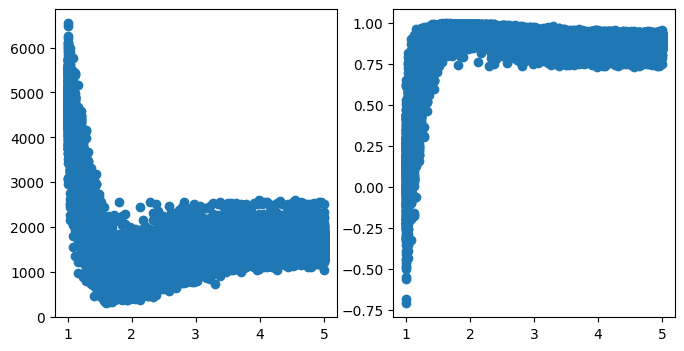

In [7]:
# load data
file_path = current_dir.parent / 'results/model_dpsi/result1.csv'
results = pd.read_csv(file_path)
print(len(results))

# calculate R^2 for distance_cum
p = 3
results["r2"] = 1 - results["distance_cum"]**2/SS_tot
results["r2_adjusted"] = 1 - (1 - results["r2"]) * (len(data) - 1)/(len(data) - p - 1)

print(results)

combined = pd.merge(sampled_df, results, left_index=True, right_on='index')
combined = combined.sort_values(by=['distance_cum'], ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(combined["dpsi"], combined["distance_cum"])
ax[1].scatter(combined["dpsi"], combined["r2_adjusted"])

Text(0, 0.5, 'Cumulative distance')

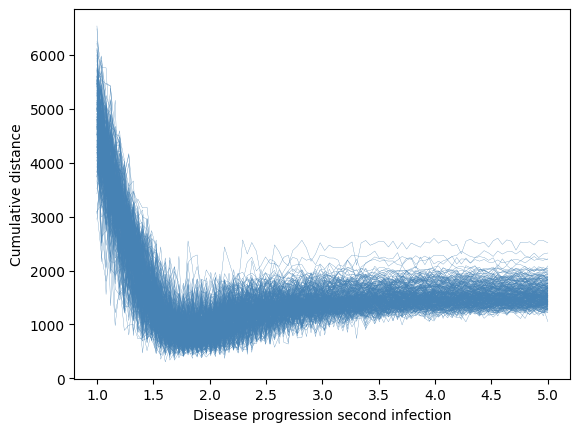

In [8]:
grouped = combined.groupby(['beta', 'diag', 'seed'])

for (beta, diag, seed), group_data in grouped:
    group_data = group_data.sort_values(by='dpsi')
    plt.plot(group_data['dpsi'], group_data['distance_cum'], color = "steelblue", linewidth = 0.2)
    group_data = group_data.sort_values(by='distance_cum')

plt.xlabel("Disease progression second infection")
plt.ylabel("Cumulative distance")

In [9]:
# select the top 100 trajectories 
combined = combined.sort_values(by='distance_cum')
file_path = current_dir.parent / 'inputs/model_dpsi/final_run.csv'
combined.loc[:99].to_csv(file_path, index = False)

print(combined.loc[:99]["r2_adjusted"].mean())
print(combined.loc[:99]["r2_adjusted"].quantile(0.025),combined.loc[:99]["r2_adjusted"].quantile(0.975))

0.9923522378926131
0.9910222319199887 0.995207363545647


## Decrease in diag after 2022

In [10]:
# is there a change in diag prob after 2022?

sampled_df = accepted_params[['beta', 'diag', 'seed']].reset_index(drop=True)
sampled_df = sampled_df.loc[sampled_df.index.repeat(100)].reset_index(drop=True)

sampled_df['diag_factor'] = np.tile(np.linspace(0.01, 0.99, 100), len(accepted_params))

print(sampled_df) 

file_path = current_dir.parent / 'inputs/model_diag/run1.csv'
sampled_df.to_csv(file_path)

           beta      diag   seed  diag_factor
0      1.771036  0.101567  49451     0.010000
1      1.771036  0.101567  49451     0.019899
2      1.771036  0.101567  49451     0.029798
3      1.771036  0.101567  49451     0.039697
4      1.771036  0.101567  49451     0.049596
...         ...       ...    ...          ...
29195  1.788586  0.106209  32314     0.950404
29196  1.788586  0.106209  32314     0.960303
29197  1.788586  0.106209  32314     0.970202
29198  1.788586  0.106209  32314     0.980101
29199  1.788586  0.106209  32314     0.990000

[29200 rows x 4 columns]


Run the following command but in batches in parallel:
```
python scripts/stochastic_model/abc_smc_full_timeline.py 0 29200 model_diag run1
```
To collect batch results and combine them into one:
```
python scripts/collect_results.py model_diag 1

29200
       index    distance  distance_cum        r2  r2_adjusted
0          0   65.954530   2063.901160  0.832255     0.829564
1          1   66.015150   1948.642348  0.850467     0.848068
2          2   65.954530   1971.853950  0.846884     0.844427
3          3   65.429351   1833.837779  0.867568     0.865443
4          4   65.939366   1684.016627  0.888323     0.886531
...      ...         ...           ...       ...          ...
29195  29195  159.496081   4297.708692  0.272647     0.260978
29196  29196  165.372307   5187.253994 -0.059611    -0.076610
29197  29197  164.182825   5371.418528 -0.136186    -0.154414
29198  29198  166.078295   4823.888266  0.083640     0.068939
29199  29199  163.398286   5488.201618 -0.186128    -0.205157

[29200 rows x 5 columns]


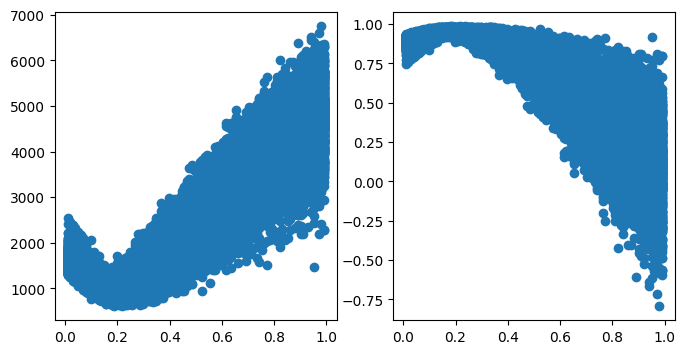

In [12]:
# load data
file_path = current_dir.parent / 'results/model_diag/result1.csv'
results = pd.read_csv(file_path)
print(len(results))

p = 3
results["r2"] = 1 - results["distance_cum"]**2/SS_tot
results["r2_adjusted"] = 1 - (1 - results["r2"]) * (len(data) - 1)/(len(data) - p - 1)

print(results)

combined = pd.merge(sampled_df, results, left_index=True, right_on='index')
combined = combined.sort_values(by=['distance_cum'], ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(combined["diag_factor"], combined["distance_cum"])
ax[1].scatter(combined["diag_factor"], combined["r2"])

In [13]:
# select the top 100 trajectories 
combined = combined.sort_values(by='distance_cum')
file_path = current_dir.parent / 'inputs/model_diag/final_run.csv'
combined.loc[:99].to_csv(file_path, index = False)

print(combined.loc[:99]["r2_adjusted"].mean())
print(combined.loc[:99]["r2_adjusted"].quantile(0.025),combined.loc[:99]["r2_adjusted"].quantile(0.975))

0.9796035134154131
0.9768299603689226 0.9841257959569389


## Decreased infectiousness of second infection (milder case)

In [15]:
sampled_df = accepted_params[['beta', 'diag', 'seed']].reset_index(drop=True)
sampled_df = sampled_df.loc[sampled_df.index.repeat(100)].reset_index(drop=True)

sampled_df['infectiousness_2nd_factor'] = np.tile(np.linspace(0.01, 0.99, 100), len(accepted_params))

print(sampled_df)

file_path = current_dir.parent / 'inputs/model_2ndinf/run1.csv'
sampled_df.to_csv(file_path)

           beta      diag   seed  infectiousness_2nd_factor
0      1.771036  0.101567  49451                   0.010000
1      1.771036  0.101567  49451                   0.019899
2      1.771036  0.101567  49451                   0.029798
3      1.771036  0.101567  49451                   0.039697
4      1.771036  0.101567  49451                   0.049596
...         ...       ...    ...                        ...
29195  1.788586  0.106209  32314                   0.950404
29196  1.788586  0.106209  32314                   0.960303
29197  1.788586  0.106209  32314                   0.970202
29198  1.788586  0.106209  32314                   0.980101
29199  1.788586  0.106209  32314                   0.990000

[29200 rows x 4 columns]


Run the following command but in batches in parallel:
```
python scripts/stochastic_model/abc_smc_full_timeline.py 0 29200 model_2ndinf run1
```
To collect batch results and combine them into one:
```
python scripts/collect_results.py model_2ndinf 1

29200
       index    distance  distance_cum        r2  r2_adjusted
0          0   66.279710   2032.077754  0.837388     0.834779
1          1   66.037868   2033.986971  0.837082     0.834469
2          2   66.249528   2033.361011  0.837183     0.834571
3          3   66.264621   2048.893360  0.834686     0.832034
4          4   66.196677   2030.845883  0.837585     0.834980
...      ...         ...           ...       ...          ...
29195  29195  164.763467   5195.636727 -0.063039    -0.080093
29196  29196  158.401389   4893.307062  0.057076     0.041949
29197  29197  160.732697   4971.392863  0.026743     0.011129
29198  29198  156.355364   4907.639351  0.051545     0.036329
29199  29199  167.573864   6035.518785 -0.434501    -0.457514

[29200 rows x 5 columns]


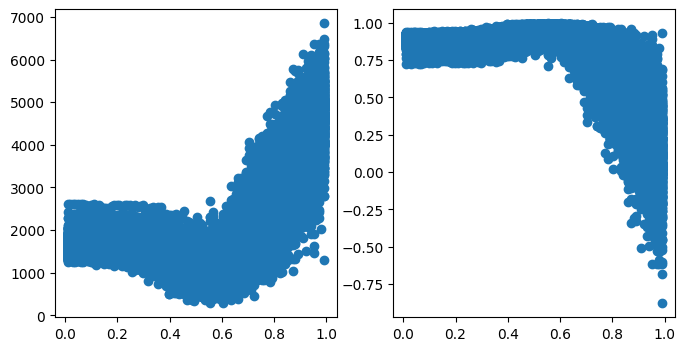

In [16]:
# load data
file_path = current_dir.parent / 'results/model_2ndinf/result1.csv'
results = pd.read_csv(file_path)
print(len(results))

# calculate R^2 for distance_cum
p = 3
results["r2"] = 1 - results["distance_cum"]**2/SS_tot
results["r2_adjusted"] = 1 - (1 - results["r2"]) * (len(data) - 1)/(len(data) - p - 1)

print(results)

combined = pd.merge(sampled_df, results, left_index=True, right_on='index')
combined = combined.sort_values(by=['distance_cum'], ascending=True).reset_index(drop=True)
#combined = combined.sort_values(by=['index'], ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(combined['infectiousness_2nd_factor'], combined["distance_cum"])
ax[1].scatter(combined['infectiousness_2nd_factor'], combined["r2_adjusted"])

In [17]:
# select the top 100 trajectories 
combined = combined.sort_values(by='distance_cum')
file_path = current_dir.parent / 'inputs/model_2ndinf/final_run.csv'
combined.loc[:99].to_csv(file_path, index = False)

print(combined.loc[:99]["r2_adjusted"].mean())
print(combined.loc[:99]["r2_adjusted"].quantile(0.025),combined.loc[:99]["r2_adjusted"].quantile(0.975))

0.9919775496977868
0.9904180110255385 0.99498482023443


## Decreased diagnosis only for second infection (also milder case) 

In [19]:
sampled_df = accepted_params[['beta', 'diag', 'seed']].reset_index(drop=True)
sampled_df = sampled_df.loc[sampled_df.index.repeat(100)].reset_index(drop=True)

# get diag probability form rate, multiply diag prob by different percentage levels, transform that back to rate and calculate factor for rate
sampled_df["diag_prob"] = 1 - ((1/scale_I)/(1/scale_I + sampled_df["diag"]))**5
sampled_df["diag_factor"] = np.tile(np.linspace(0.01, 0.99, 100), len(accepted_params))
sampled_df["diag_prob2"] = sampled_df["diag_prob"] * sampled_df["diag_factor"]
sampled_df["diag_rate2"] = 5/2 * ((1- sampled_df["diag_prob2"])**(-1/5) -1)
sampled_df["diag_2nd_factor"] = sampled_df["diag_rate2"]/sampled_df["diag"]

#sampled_df = sampled_df.drop(["diag_prob","diag_factor","diag_prob2","diag_rate2"], axis = 1)

file_path = current_dir.parent / 'inputs/model_2nddiag/run1.csv'
sampled_df[['beta', 'diag', 'seed', "diag_2nd_factor"]].to_csv(file_path)

Run the following command but in batches in parallel:
```
python scripts/stochastic_model/abc_smc_full_timeline.py 0 29200 model_2nddiag run1
```
To collect batch results and combine them into one:
```
python scripts/collect_results.py model_2nddiag 1

29200
       index    distance  distance_cum        r2  r2_adjusted
0          0   81.437092   2017.816890  0.839663     0.837090
1          1   80.919713   2265.814864  0.797828     0.794585
2          2   79.668061   2250.827181  0.800494     0.797293
3          3   81.184974   1757.568491  0.878354     0.876403
4          4   80.572948   2129.732143  0.821384     0.818518
...      ...         ...           ...       ...          ...
29195  29195  163.957312   5039.832239 -0.000239    -0.016285
29196  29196  163.168624   5618.205852 -0.242988    -0.262929
29197  29197  163.416645   5382.666811 -0.140950    -0.159254
29198  29198  164.538749   6084.939194 -0.458089    -0.481481
29199  29199  164.544827   6446.814485 -0.636673    -0.662930

[29200 rows x 5 columns]


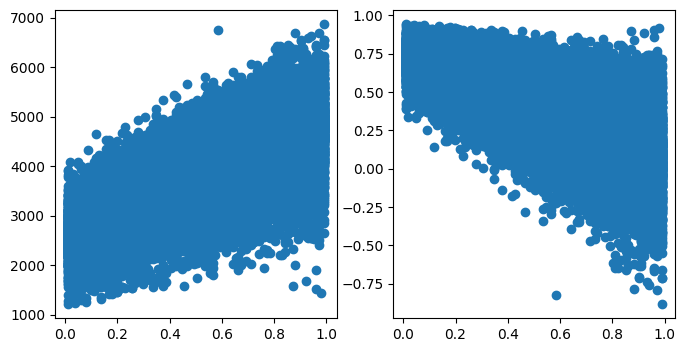

In [20]:
# load data
file_path = current_dir.parent / 'results/model_2nddiag/result1.csv'
results = pd.read_csv(file_path)
print(len(results))

# calculate R^2 for distance_cum
p = 3
results["r2"] = 1 - results["distance_cum"]**2/SS_tot
results["r2_adjusted"] = 1 - (1 - results["r2"]) * (len(data) - 1)/(len(data) - p - 1)

print(results)

combined = pd.merge(sampled_df, results, left_index=True, right_on='index')
combined = combined.sort_values(by=['distance_cum'], ascending=True).reset_index(drop=True)
#combined = combined.sort_values(by=['index'], ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(combined["diag_factor"], combined["distance_cum"])
ax[1].scatter(combined["diag_factor"], combined["r2_adjusted"])

In [21]:
# select the top 100 trajectories 
combined = combined.sort_values(by='distance_cum')
file_path = current_dir.parent / 'inputs/model_2nddiag/final_run.csv'
combined.loc[:99].to_csv(file_path, index = False)

print(combined.loc[:99]["r2_adjusted"].mean())
print(combined.loc[:99]["r2_adjusted"].quantile(0.025),combined.loc[:99]["r2_adjusted"].quantile(0.975))

0.9034741598199563
0.8859233253932942 0.9360569398760741


# Mpox long shedding

In [22]:
sampled_df = accepted_params[['beta', 'diag', 'seed']].reset_index(drop=True)
sampled_df = sampled_df.loc[sampled_df.index.repeat(100)].reset_index(drop=True)

sampled_df['long_mpox_prob'] = np.tile(np.linspace(0.01, 0.25, 100), len(accepted_params))

print(sampled_df)

file_path = current_dir.parent / 'inputs/model_long/run1.csv'
sampled_df.to_csv(file_path)

           beta      diag   seed  long_mpox_prob
0      1.771036  0.101567  49451        0.010000
1      1.771036  0.101567  49451        0.012424
2      1.771036  0.101567  49451        0.014848
3      1.771036  0.101567  49451        0.017273
4      1.771036  0.101567  49451        0.019697
...         ...       ...    ...             ...
29195  1.788586  0.106209  32314        0.240303
29196  1.788586  0.106209  32314        0.242727
29197  1.788586  0.106209  32314        0.245152
29198  1.788586  0.106209  32314        0.247576
29199  1.788586  0.106209  32314        0.250000

[29200 rows x 4 columns]


29200
       index    distance  distance_cum         r2  r2_adjusted
0          0  102.230133   5151.737959  -0.045151    -0.061918
1          1  118.953773   6415.050896  -0.620585    -0.646584
2          2  112.756375   5897.496757  -0.369642    -0.391615
3          3  111.314869   5826.335812  -0.336788    -0.358234
4          4  129.015503   7026.964138  -0.944496    -0.975691
...      ...         ...           ...        ...          ...
29195  29195  462.729943  37617.598116 -54.725464   -55.619455
29196  29196  465.880886  37638.782685 -54.788246   -55.683244
29197  29197  466.126592  37852.478519 -55.423524   -56.328715
29198  29198  464.207928  37688.509270 -54.935753   -55.833118
29199  29199  429.847647  35659.803280 -49.075979   -49.879337

[29200 rows x 5 columns]


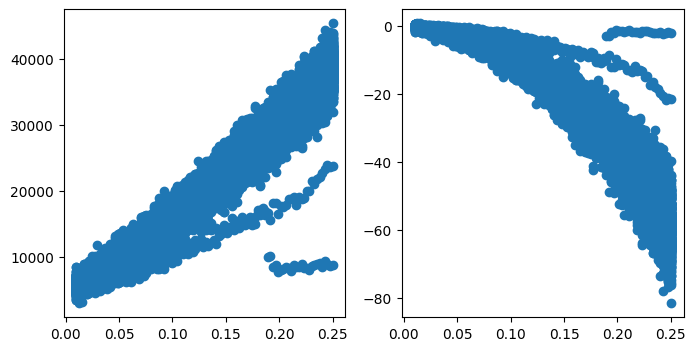

In [23]:
# load data
file_path = current_dir.parent / 'results/model_long/result1.csv'
results = pd.read_csv(file_path)
print(len(results))

# calculate R^2 for distance_cum
p = 3
results["r2"] = 1 - results["distance_cum"]**2/SS_tot
results["r2_adjusted"] = 1 - (1 - results["r2"]) * (len(data) - 1)/(len(data) - p - 1)

print(results)

combined = pd.merge(sampled_df, results, left_index=True, right_on='index')
combined = combined.sort_values(by=['distance_cum'], ascending=True).reset_index(drop=True)
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].scatter(combined["long_mpox_prob"], combined["distance_cum"])
ax[1].scatter(combined["long_mpox_prob"], combined["r2_adjusted"])

In [24]:
# select the top 100 trajectories 
combined = combined.sort_values(by='distance_cum')
file_path = current_dir.parent / 'inputs/model_long/final_run.csv'
combined.loc[:99].to_csv(file_path, index = False)

print(combined.loc[:99]["r2_adjusted"].mean())
print(combined.loc[:99]["r2_adjusted"].quantile(0.025),combined.loc[:99]["r2_adjusted"].quantile(0.975))

0.16323923321689582
0.013362782152639955 0.5218599472149139
